# Part A - Business-Level Clustering (notebook)

### Imports

In [37]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# For data cleaning. data_prep is used in both notebook and app.py files
from data_prep import (
    load_raw,
    clean_businesses,
    geo_subset,
    TOP_N_BUSINESS_TYPES,
)

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## A1 — Data acquisition and cleaning

- Load the GeoJSON and inspect structure, types, and missingness yourself
- Decide how to handle records with no geographic coordinates, and missing `numberofemployees`/`feepaid` — justify your choice
- Filter to a sensible subset (e.g., `status == "Issued"`) and justify
businesstype has ~94 categories, many sparse — decide how to consolidate (e.g., keep the top N, group the rest as "Other")
- **Optional refinement to try:** combine `businesstype` and `businesssubtype` into a single, more fine-grained industry label where a subtype exists (falling back to `businesstype` alone where it doesn't). This gives you a sharper industry signal for some categories — worth comparing against `businesstype` alone.
- Keep your sample size manageable for both plotting and later Streamlit responsiveness — the Build Guide covers this

> **Hints:**
> - Load the GeoJSON with `geopandas.read_file()` (gives you a ready-to-use `geometry` column), or with `json.load()` + `pd.json_normalize(data["features"])` if you'd rather stick with plain pandas — either is fine.
> - The fields you actually need live under each feature's `properties` — if `pd.json_normalize` doesn't flatten them automatically, pass `record_path`/prefix arguments, or normalize `[f["properties"] for f in data["features"]]` directly.
> - `geo_point_2d`/`geometry` is what gives you usable latitude/longitude — a business without it can't be placed on a map or used in A2's location clustering, so those rows are natural candidates to drop (but say so explicitly).
> - A fast way to decide what to do with a column: `df["column"].isna().mean()`. Run it on `numberofemployees`, `feepaid`, `businesssubtype`, and `postalcode` before deciding.
> - For consolidating `businesstype`, `df["businesstype"].value_counts()` shows you the long tail directly — a defensible approach is keeping however many categories cover ~80–90% of records and bucketing the rest as "Other."
> - `status` has values beyond `Issued` (pending, cancelled, gone out of business, etc.) — `df["status"].value_counts()` shows what you're including or excluding.
> - You don't need to hand-fix every messy field (inconsistent `province` values, duplicate `licencenumber` from revisions, etc.) — a reasonable, clearly justified pass on the columns your features actually use is enough.

> **Markdown required:** Document each cleaning decision and why you made it.

In [38]:
gdf_raw = load_raw()
print(gdf_raw.shape)
gdf_raw.dtypes

(203876, 26)


folderyear                                     str
licencersn                                     str
licencenumber                                  str
licencerevisionnumber                          str
businessname                                   str
businesstradename                              str
status                                         str
issueddate                     datetime64[ms, UTC]
expireddate                         datetime64[ms]
businesstype                                   str
businesssubtype                                str
unit                                           str
unittype                                       str
house                                          str
street                                         str
city                                           str
province                                       str
country                                        str
postalcode                                     str
localarea                      

In [39]:
# Show which columns have the most missing values
gdf_raw.isna().mean().sort_values(ascending=False)

geom                     1.000000
businesssubtype          0.894686
unittype                 0.761630
unit                     0.760335
businesstradename        0.621358
geo_point_2d             0.497533
geometry                 0.497533
postalcode               0.466171
house                    0.462551
street                   0.462467
feepaid                  0.370279
country                  0.219374
issueddate               0.141576
expireddate              0.141468
businessname             0.066040
localarea                0.013312
province                 0.000387
city                     0.000270
businesstype             0.000000
status                   0.000000
licencerevisionnumber    0.000000
licencenumber            0.000000
folderyear               0.000000
licencersn               0.000000
numberofemployees        0.000000
extractdate              0.000000
dtype: float64

In [40]:
gdf_raw["status"].value_counts()

status
Issued                  166856
Pending                  15271
Gone Out of Business     10163
Inactive                  6447
Cancelled                 5139
Name: count, dtype: int64

### Cleaning decisions

**Cleaning 1 - `status` filter.** Keep only `Issued` rows becuase these only represent businesses that are active.

**Cleaning 2 - `geom` column.** Remove all of geom column because it is 100% missing on every row. Nothing todo in the code. I am ignoring this column.

**Cleaning 3 - missing coordinates.** Half of rows have no location (mostly things like Short-term Rental Operators with no fixed storefront). Rather than dropping them, keep them and flag with `has_geo`, only dropping when a step actually needs lat/lon.

**Cleaning 4 - `businesssubtype`.** Most are missing, too sparse to be useful. This does not add much more categorisation. `businesstype` is more useful. Nothing todo in the code. I am ignoring this column.

**Cleaning 5 - `postalcode`.** Half are missing, too incomplete. Use `localarea` instead because only  a few area missing.

**Cleaning 6 - `feepaid` imputation.** Some are missing. Fill with the median fee for that business's `businesstype`, falling back to the overall median if a type has no observed fees at all.

**Cleaning 7 - `businesstype` consolidation.** 94 long-tailed categories. Keep the top 20 (covers most of the records) and bucket everything else as `"Other"`.

In [41]:
# Check how much of the data is covered by just the top business types
vc = gdf_raw.loc[gdf_raw["status"] == "Issued", "businesstype"].value_counts()
cum_share = vc.cumsum() / vc.sum()
print("n categories:", vc.shape[0])
for n in (15, 18, 20, 25, 30):
    print(f"top {n} categories cover {cum_share.iloc[n - 1]:.1%}")
vc.head(20)

n categories: 94
top 15 categories cover 76.7%
top 18 categories cover 80.4%
top 20 categories cover 82.5%
top 25 categories cover 86.0%
top 30 categories cover 88.7%


businesstype
Long-term Rental                          39961
Health Care Professionals and Services    15313
General Contractor                        12562
Short-term Rental Operator                 9944
Retail Dealer                              7530
Consulting and Management Services         5679
Legal Services                             5562
Trade Contractor                           5422
Restaurant                                 5087
Beauty Services                            4400
Business Support Services                  4041
Limited Service Food Establishment         4022
Financial Services                         3050
Real Estate Services                       2715
Information Communication Technology       2686
Retail Dealer - Food                       2154
Wholesale Dealer - Non-Food                2061
Association or Society                     1998
Architectural and Engineering Services     1761
Building Repair and Maintenance            1724
Name: count, dtype: int64

In [42]:
# Run the full cleaning process from data_prep.py to filter for issued status, 
# fill in missing fee data, group business types, and fix date formats.
df = clean_businesses(gdf_raw, top_n=TOP_N_BUSINESS_TYPES)
print(df.shape)
print("has_geo:", df["has_geo"].mean())
df[["businesstype", "businesstype_grouped", "numberofemployees", "feepaid", "lat", "lon", "has_geo"]].head()

(166856, 30)
has_geo: 0.5142817759025746


,businesstype,businesstype_grouped,numberofemployees,feepaid,lat,lon,has_geo
1,Long-term Rental,Long-term Rental,0.0,226.0,49.257736,-123.088157,True
2,Long-term Rental,Long-term Rental,0.0,275.0,49.258053,-123.089564,True
3,Long-term Rental,Long-term Rental,0.0,188.0,49.248896,-123.096462,True
4,Long-term Rental,Long-term Rental,0.0,437.0,49.275461,-123.066152,True
5,Long-term Rental,Long-term Rental,0.0,282.0,49.279366,-123.059579,True


## A2 — Location-only clustering: K-means vs. DBSCAN

Using **only latitude/longitude**, cluster the businesses two ways:

- **K-means:** use the elbow method to choose K, then fit
- **DBSCAN:** choose `eps`/`min_samples` reasonably (some trial and error expected)
- Produce a **static plot** (matplotlib) of the points colored by cluster assignment, one for each method

> **Markdown required:**
> 1. How do the K-means clusters map onto actual Vancouver geography — do they correspond to anything you'd recognize (downtown core, west side, etc.)?
> 2. How do the DBSCAN clusters compare? Where do the two methods agree or disagree, and why — think about what each algorithm assumes about cluster shape and density, and what DBSCAN's "noise" points represent.

(20000, 30)


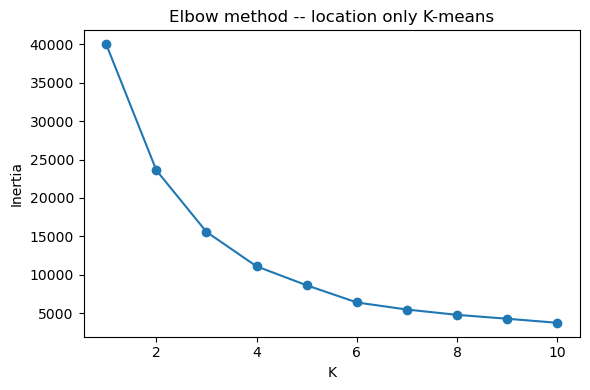

In [43]:
# In Vancouver, degrees of longitude are narrower than degrees of latitude. 
# I will scale both coordinates to prevent the K-means from thinking that north south 
# distances are more important than east west distances.

#BEGIN
geo_df = geo_subset(df, n_sample=20000, random_state=RANDOM_STATE)
print(geo_df.shape)
geo_df[["lat", "lon", "businesstype_grouped", "localarea"]].head()

coord_scaler = StandardScaler()
coords_scaled = coord_scaler.fit_transform(geo_df[["lat", "lon"]])

inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(coords_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow method -- location only K-means")
plt.tight_layout()
plt.show()
#END

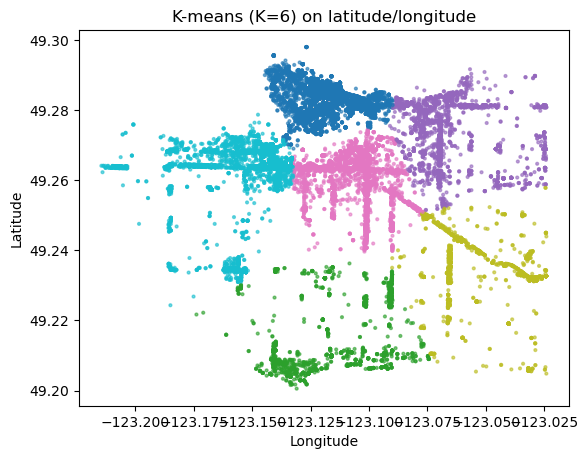

In [44]:
# There are diminishing returns when adding more than 6 clusters.

#BEGIN
K_LOCATION = 6
kmeans_geo = KMeans(n_clusters=K_LOCATION, random_state=RANDOM_STATE, n_init=10)
geo_df["kmeans_cluster"] = kmeans_geo.fit_predict(coords_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(
    geo_df["lon"], geo_df["lat"], c=geo_df["kmeans_cluster"], cmap="tab10", s=4, alpha=0.6
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"K-means (K={K_LOCATION}) on latitude/longitude")
plt.gca().set_aspect(1.5)
plt.tight_layout()
plt.show()
#END

In [45]:
# Find the main neighborhoods that make up each group

#BEGIN
for c in sorted(geo_df["kmeans_cluster"].unique()):
    top_areas = geo_df.loc[geo_df["kmeans_cluster"] == c, "localarea"].value_counts(
        normalize=True
    ).head(3)
    print(f"cluster {c} (n={ (geo_df['kmeans_cluster'] == c).sum() }): "
          + ", ".join(f"{a} {p:.0%}" for a, p in top_areas.items()))
#END

cluster 0 (n=7886): Downtown 79%, West End 15%, Strathcona 5%
cluster 1 (n=1559): Marpole 46%, Sunset 38%, Oakridge 8%
cluster 2 (n=2316): Grandview-Woodland 44%, Hastings-Sunrise 19%, Strathcona 18%
cluster 3 (n=3722): Mount Pleasant 38%, Fairview 35%, Riley Park 13%
cluster 4 (n=1274): Renfrew-Collingwood 37%, Kensington-Cedar Cottage 32%, Victoria-Fraserview 18%
cluster 5 (n=3243): Kitsilano 43%, Fairview 34%, Arbutus-Ridge 7%


In [46]:
# I experimented with search radiuses (eps) and group size limits (min_samples) 
# to find the best settings for clustering the scaled data.

#BEGIN
for eps in (0.08, 0.12, 0.17, 0.2, 0.25, 0.35):
    for min_samples in (15, 25, 40):
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(coords_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_frac = (labels == -1).mean()
        print(f"eps={eps:<5} min_samples={min_samples:<3} -> clusters={n_clusters:<3} noise={noise_frac:.1%}")
#END

eps=0.08  min_samples=15  -> clusters=50  noise=3.1%
eps=0.08  min_samples=25  -> clusters=43  noise=5.5%
eps=0.08  min_samples=40  -> clusters=36  noise=11.9%
eps=0.12  min_samples=15  -> clusters=27  noise=1.9%
eps=0.12  min_samples=25  -> clusters=26  noise=2.7%
eps=0.12  min_samples=40  -> clusters=17  noise=5.3%
eps=0.17  min_samples=15  -> clusters=19  noise=1.2%
eps=0.17  min_samples=25  -> clusters=18  noise=1.5%
eps=0.17  min_samples=40  -> clusters=13  noise=3.3%
eps=0.2   min_samples=15  -> clusters=14  noise=0.9%
eps=0.2   min_samples=25  -> clusters=15  noise=1.2%
eps=0.2   min_samples=40  -> clusters=12  noise=2.7%
eps=0.25  min_samples=15  -> clusters=6   noise=0.3%
eps=0.25  min_samples=25  -> clusters=11  noise=0.4%
eps=0.25  min_samples=40  -> clusters=8   noise=1.1%
eps=0.35  min_samples=15  -> clusters=1   noise=0.1%
eps=0.35  min_samples=25  -> clusters=1   noise=0.1%
eps=0.35  min_samples=40  -> clusters=1   noise=0.1%


clusters=15, noise=1.2%


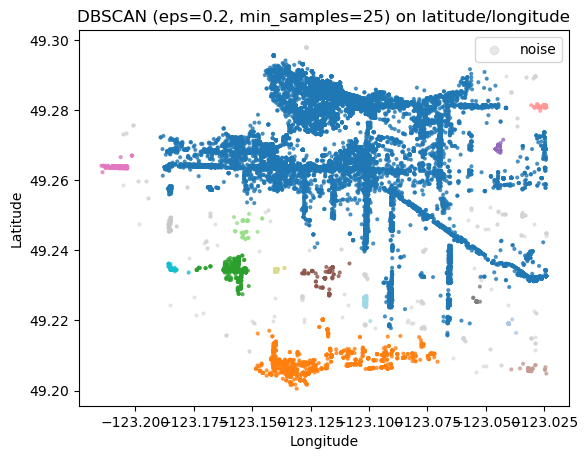

In [47]:
# A small radius cuts the city into too many tiny pieces, while a large radius 
# groups everything into one giant blob because Vancouver's businesses are too continuous. 
# Setting eps=0.2 and min_samples=25 gives the best balance.

#BEGIN
EPS, MIN_SAMPLES = 0.2, 25
dbscan_geo = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
geo_df["dbscan_cluster"] = dbscan_geo.fit_predict(coords_scaled)

n_clusters = geo_df.loc[geo_df["dbscan_cluster"] != -1, "dbscan_cluster"].nunique()
print(f"clusters={n_clusters}, noise={(geo_df['dbscan_cluster'] == -1).mean():.1%}")

plt.figure(figsize=(6, 6))
is_noise = geo_df["dbscan_cluster"] == -1
plt.scatter(
    geo_df.loc[is_noise, "lon"], geo_df.loc[is_noise, "lat"],
    c="lightgray", s=4, alpha=0.5, label="noise",
)
plt.scatter(
    geo_df.loc[~is_noise, "lon"], geo_df.loc[~is_noise, "lat"],
    c=geo_df.loc[~is_noise, "dbscan_cluster"], cmap="tab20", s=4, alpha=0.7,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) on latitude/longitude")
plt.gca().set_aspect(1.5)
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()
#END

In [48]:
# Check which neighborhoods make up each group, 
# and find out where the isolated businesses are scattered.

#BEGIN
for c in sorted(geo_df.loc[geo_df["dbscan_cluster"] != -1, "dbscan_cluster"].unique()):
    top_areas = geo_df.loc[geo_df["dbscan_cluster"] == c, "localarea"].value_counts(
        normalize=True
    ).head(2)
    n = (geo_df["dbscan_cluster"] == c).sum()
    print(f"cluster {c:>2} (n={n:<5}): " + ", ".join(f"{a} {p:.0%}" for a, p in top_areas.items()))

print()
print("noise points by localarea:")
print(geo_df.loc[geo_df["dbscan_cluster"] == -1, "localarea"].value_counts(normalize=True).head(8))
#END

cluster  0 (n=17690): Downtown 35%, Fairview 14%
cluster  1 (n=37   ): Killarney 100%
cluster  2 (n=1038 ): Marpole 69%, Sunset 26%
cluster  3 (n=362  ): Kerrisdale 56%, Arbutus-Ridge 38%
cluster  4 (n=42   ): Arbutus-Ridge 90%, Shaughnessy 10%
cluster  5 (n=47   ): Hastings-Sunrise 100%
cluster  6 (n=59   ): Hastings-Sunrise 100%
cluster  7 (n=131  ): Oakridge 70%, South Cambie 21%
cluster  8 (n=40   ): Killarney 100%
cluster  9 (n=89   ): West Point Grey 100%
cluster 10 (n=31   ): Victoria-Fraserview 100%
cluster 11 (n=35   ): Dunbar-Southlands 100%
cluster 12 (n=25   ): Kerrisdale 52%, Shaughnessy 44%
cluster 13 (n=55   ): Dunbar-Southlands 98%, Kerrisdale 2%
cluster 14 (n=74   ): Sunset 100%

noise points by localarea:
localarea
Renfrew-Collingwood    0.208163
Sunset                 0.122449
Victoria-Fraserview    0.102041
Killarney              0.089796
Hastings-Sunrise       0.081633
Oakridge               0.061224
Kerrisdale             0.057143
West Point Grey        0.053061
N

### A2 - K-means vs. DBSCAN

**1. K-means (K=6) maps cleanly onto real Vancouver neighbourhoods.** Each cluster is dominated by a recognizable area. K-means splits the city into 6 compact, contiguous areas that match how a local would describe Vancouver's areas.

**2. DBSCAN (eps=0.2, min_samples=25): ther is one giant cluster that incldues Downtown** Business density there is high and uniform with no real gaps. The other 16 small clusters sit in lower density outer neighbourhoods that do have gaps: Sunset, Marpole, Oakridge, Dunbar-Southlands, Shaughnessy/Kerrisdale, West Point Grey, Killarney, Victoria-Fraserview, Hastings-Sunrise, Arbutus-Ridge.

**Why they differ.** K-means always carves the map into K similarly sized regions regardless of density, so it slices the uniform urban core into separate areas. DBSCAN only splits where there's an actual density gap, so it keeps the core as one cluster but correctly separates the sparser outer neighbourhoods. Both methods agree those outer areas are distinct. DBSCAN just carves them out explicitly instead of forcing them into a nearby area.

**DBSCAN's noise** are isolated businesses in lower density areas with too few nearby neighbours to join a cluster. K-means has no "noise" option. It would force these into the closest area even when that's a poor fit.

## A3 — Feature-based clustering: Size, Industry, Lifecycle

Engineer and scale features from:

- **Size** — number of employees, fee paid
- **Industry** — your consolidated business type (or type+subtype) categories, encoded
- **Lifecycle** — licence duration (`expireddate − issueddate`), month issued (cyclically encoded), licence revision number
- (Feel free to include other features you think are useful)

Run a simple K-means clustering on the combined, scaled feature set, then apply PCA to project to 2D and visualize the clusters.

> **Markdown required:** What do the resulting clusters seem to represent? Does this differ from the purely geographic clustering in A2?

> **Optional/suggested (not required):** Profile each cluster using z-scores of the input features (as shown in lecture) to name each cluster — a nice way to deepen your interpretation, but not graded as a separate requirement.

In [54]:
feat_df = geo_df.copy()

# --- Size ---
# Apply a log scale to shrink the massive gap between small businesses and corporate giants.
feat_df["log_employees"] = np.log1p(feat_df["numberofemployees"])
feat_df["log_feepaid"] = np.log1p(feat_df["feepaid"])

# --- Lifecycle ---
feat_df["licence_duration_days"] = (feat_df["expireddate"] - feat_df["issueddate"]).dt.days
feat_df["licence_duration_days"] = feat_df["licence_duration_days"].fillna(
    feat_df["licence_duration_days"].median()
)

issue_month = feat_df["issueddate"].dt.month
issue_month = issue_month.fillna(issue_month.median())
feat_df["issue_month_sin"] = np.sin(2 * np.pi * issue_month / 12)
feat_df["issue_month_cos"] = np.cos(2 * np.pi * issue_month / 12)

feat_df["licence_revision"] = pd.to_numeric(
    feat_df["licencerevisionnumber"], errors="coerce"
).fillna(0)

# --- Industry ---
industry_dummies = pd.get_dummies(feat_df["businesstype_grouped"], prefix="biz")

numeric_cols = [
    "log_employees", "log_feepaid", "licence_duration_days",
    "issue_month_sin", "issue_month_cos", "licence_revision",
]
X_raw = pd.concat([feat_df[numeric_cols], industry_dummies], axis=1)
print(X_raw.shape)
X_raw.head()

(20000, 26)


,log_employees,log_feepaid,licence_duration_days,issue_month_sin,issue_month_cos,licence_revision,biz_Architectural and Engineering Services,biz_Association or Society,biz_Beauty Services,biz_Building Repair and Maintenance,biz_Business Support Services,biz_Consulting and Management Services,biz_Financial Services,biz_General Contractor,biz_Health Care Professionals and Services,biz_Information Communication Technology,biz_Legal Services,biz_Limited Service Food Establishment,biz_Long-term Rental,biz_Other,biz_Real Estate Services,biz_Restaurant,biz_Retail Dealer,biz_Retail Dealer - Food,biz_Trade Contractor,biz_Wholesale Dealer - Non-Food
0,7.313887,5.805135,320.0,8.660254e-01,0.500000,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1.098612,6.493754,382.0,-2.449294e-16,1.000000,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,1.609438,3.912023,347.0,5.000000e-01,0.866025,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,1.386294,5.583496,365.0,-2.449294e-16,1.000000,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,2.397895,5.627621,408.0,-5.000000e-01,0.866025,0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


In [55]:
#BEGIN
# Standardize all columns so they carry equal weight in the algorithm.
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X_raw)

# Match the group count to our previous map based analysis for an easy side-by-side comparison.
K_FEATURES = K_LOCATION
kmeans_feat = KMeans(n_clusters=K_FEATURES, random_state=RANDOM_STATE, n_init=10)
feat_df["feature_cluster"] = kmeans_feat.fit_predict(X_scaled)

feat_df["feature_cluster"].value_counts().sort_index()
#END

feature_cluster
0    8422
1     703
2    2418
3    6812
4    1234
5     411
Name: count, dtype: int64

explained variance ratio: [0.0711759  0.06651047] sum: 0.1376863758393428


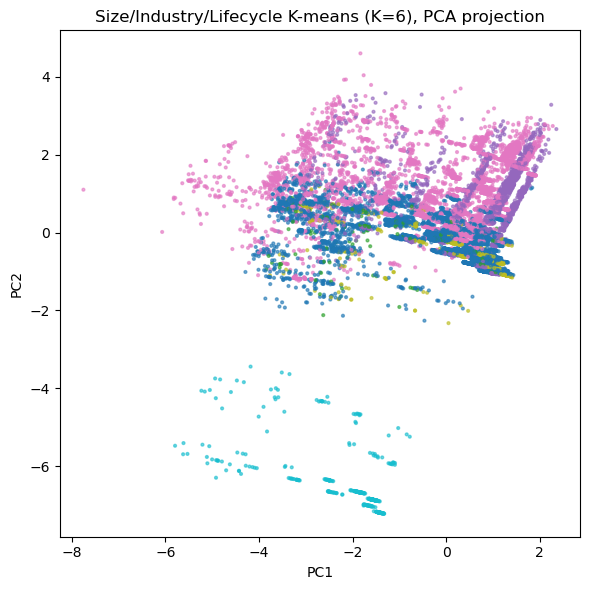

In [56]:
# PCA to 2D for visualization
#BEGIN
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords_2d = pca.fit_transform(X_scaled)
feat_df["pca1"], feat_df["pca2"] = coords_2d[:, 0], coords_2d[:, 1]
print("explained variance ratio:", pca.explained_variance_ratio_, "sum:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(6, 6))
plt.scatter(feat_df["pca1"], feat_df["pca2"], c=feat_df["feature_cluster"], cmap="tab10", s=4, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Size/Industry/Lifecycle K-means (K={K_FEATURES}), PCA projection")
plt.tight_layout()
plt.show()
#END

In [57]:
# Measure how well trait based groups match up with map based groups.
#BEGIN
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(feat_df["kmeans_cluster"], feat_df["feature_cluster"])
print(f"Adjusted Rand Index (A2 geo clusters vs A3 feature clusters): {ari:.3f}")
print("(0 = no better than random agreement, 1 = identical partitions)")

pd.crosstab(feat_df["kmeans_cluster"], feat_df["feature_cluster"])
#END

Adjusted Rand Index (A2 geo clusters vs A3 feature clusters): -0.007
(0 = no better than random agreement, 1 = identical partitions)


feature_cluster,0,1,2,3,4,5
kmeans_cluster,,,,,,
0,3211,470,495,2405,1107,198
1,668,25,230,607,10,19
2,766,34,375,1074,6,61
3,1693,102,523,1301,47,56
4,646,10,116,460,12,30
5,1438,62,679,965,52,47


In [58]:
cluster_means = pd.DataFrame(X_scaled, columns=X_raw.columns, index=feat_df.index).groupby(
    feat_df["feature_cluster"]
).mean()

# Separate the numeric traits from the category traits. 
# It is easier to see the most popular business types by name than to look at their averages.
print("z-scores (Size/Lifecycle features):")
display(cluster_means[numeric_cols].round(2))

print("\ntop businesstype per feature cluster:")
for c in sorted(feat_df["feature_cluster"].unique()):
    top = feat_df.loc[feat_df["feature_cluster"] == c, "businesstype_grouped"].value_counts(
        normalize=True
    ).head(3)
    print(f"cluster {c}: " + ", ".join(f"{t} {p:.0%}" for t, p in top.items()))

z-scores (Size/Lifecycle features):


,log_employees,log_feepaid,licence_duration_days,issue_month_sin,issue_month_cos,licence_revision
feature_cluster,,,,,,
0,0.02,-0.14,0.02,-0.04,0.00,0.00
1,0.42,-0.21,0.06,-0.08,0.02,0.09
2,-1.17,0.28,0.17,0.06,0.17,0.04
3,0.31,0.37,-0.14,0.05,-0.11,-0.05
4,-0.00,-0.20,0.21,-0.04,0.21,0.09
5,0.52,-4.00,0.14,-0.10,0.04,0.06



top businesstype per feature cluster:
cluster 0: Health Care Professionals and Services 32%, Retail Dealer 17%, Beauty Services 11%
cluster 1: Business Support Services 100%
cluster 2: Long-term Rental 100%
cluster 3: Other 68%, Restaurant 17%, Limited Service Food Establishment 13%
cluster 4: Legal Services 100%
cluster 5: Association or Society 100%


### A3 - Size/Industry/Lifecycle clusters

- **Cluster 0** - Health Care, Retail Dealer, Beauty Services
- **Cluster 1** - Business Support Services
- **Cluster 2** - Long Term Rental
- **Cluster 3** - Other
- **Cluster 4** - Legal Services
- **Cluster 5** - Asociation or Society

**Does this differ from A2's geographic clustering? Yes.** It is very differnt from A2 because there does not seem to be a corralation between the location and the type of business. Every feature cluster is spread evenly across all six geographic clusters. Where a business is located shows almost nothing about what kind of business it is, its size, or its lifecycle.